In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

# Preferred method: Victorian catchment management areas

Shapefiles from: https://discover.data.vic.gov.au/dataset/catchment-management-authority-boundaries

In [3]:
catchment_file = '/g/data/xv83/dbi599/vicwaci/shapefiles/CMA100.shp'
catchment_gdf = gp.read_file(catchment_file)
catchment_gdf

,CMA_NO,CMANAME,AREASQM,HECTARES,URL,CALP_REGIO,geometry
0,3,Glenelg Hopkins,2.672939e+10,2.672939e+06,http://www.ghcma.vic.gov.au,Glenelg Hopkins,"MULTIPOLYGON (((142.68447 -38.49841, 142.68427..."
1,9,West Gippsland,1.723597e+10,1.723597e+06,http://www.wgcma.vic.gov.au,West Gippsland,"MULTIPOLYGON (((145.89875 -38.84578, 145.89863..."
2,10,East Gippsland,2.104762e+10,2.104762e+06,http://www.egcma.com.au,East Gippsland,"MULTIPOLYGON (((148.74413 -37.80598, 148.74411..."
3,5,Corangamite,1.337104e+10,1.337104e+06,http://www.ccma.vic.gov.au,Corangamite,"MULTIPOLYGON (((142.82199 -38.57731, 142.82189..."
4,7,Melbourne Water,1.278287e+10,1.278287e+06,https://www.melbournewater.com.au,Port Phillip and Westernport,"MULTIPOLYGON (((145.21041 -38.32672, 145.21045..."
5,1,Mallee,3.932412e+10,3.932412e+06,https://malleecma.com.au,Mallee,"POLYGON ((140.96928 -33.9972, 140.97066 -33.99..."
6,6,Goulburn Broken,2.406067e+10,2.406067e+06,https://www.gbcma.vic.gov.au,Goulburn Broken,"POLYGON ((145.53408 -35.80528, 145.53391 -35.8..."
7,4,North Central,2.965354e+10,2.965354e+06,http://www.nccma.vic.gov.au,North Central,"POLYGON ((143.56435 -35.20302, 143.56467 -35.2..."
8,2,Wimmera,2.344982e+10,2.344982e+06,http://www.wcma.vic.gov.au,Wimmera,"POLYGON ((142.88353 -36.08178, 142.88349 -36.0..."
9,8,North East,1.979855e+10,1.979855e+06,http://www.necma.vic.gov.au,North East,"POLYGON ((147.71696 -35.9434, 147.71717 -35.94..."


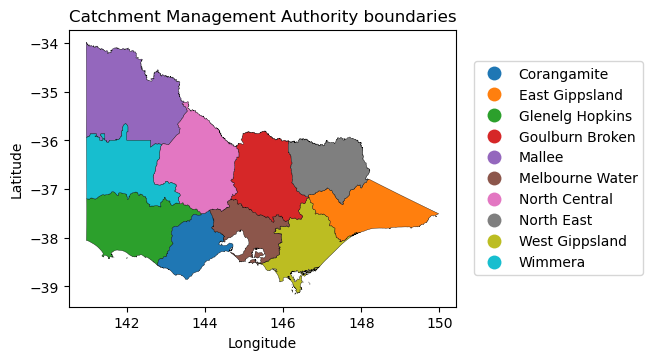

In [4]:
catchment_gdf.plot(
    figsize=[5, 5],
    column='CMANAME',
    cmap='tab10',
    legend=True,
    linewidth=0.25,
    edgecolor='black',
    legend_kwds={'loc': 'right', 'bbox_to_anchor': (1.5, 0.5)},
)
plt.title('Catchment Management Authority boundaries')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [5]:
merged_catchment_indexes = {
    'South-East Victoria': [1,2],
    'South-West Victoria': [0,3,4],
    'North-East Victoria': [6,9],
    'North-West Victoria': [5,7,8],
}

In [6]:
def merge_catchments(new_name):
    """Merge catchment management authorities."""

    indexes = merged_catchment_indexes[new_name]
    catchment_selection_gdf = catchment_gdf.iloc[indexes]
    merged_gdf = catchment_selection_gdf.dissolve()
    merged_gdf = merged_gdf.drop(columns=['CMA_NO', 'AREASQM', 'HECTARES', 'URL', 'CALP_REGIO', 'CMANAME'])
    merged_gdf['REGION_NAME'] = new_name
    merged_gdf['CATCHMENTS'] = ", ".join(list(catchment_selection_gdf['CALP_REGIO'].values))

    return merged_gdf

In [11]:
se_gdf = merge_catchments('South-East Victoria')
se_gdf.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/south_east_victoria.shp')
se_gdf

,geometry,REGION_NAME,CATCHMENTS
0,"MULTIPOLYGON (((146.296 -39.15639, 146.29607 -...",South-East Victoria,"West Gippsland, East Gippsland"


In [12]:
sw_gdf = merge_catchments('South-West Victoria')
sw_gdf.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/south_west_victoria.shp')
sw_gdf

,geometry,REGION_NAME,CATCHMENTS
0,"MULTIPOLYGON (((142.81631 -38.58161, 142.81638...",South-West Victoria,"Glenelg Hopkins, Corangamite, Port Phillip and..."


In [13]:
ne_gdf = merge_catchments('North-East Victoria')
ne_gdf.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/north_east_victoria.shp')
ne_gdf

,geometry,REGION_NAME,CATCHMENTS
0,"POLYGON ((145.53391 -35.80566, 145.53388 -35.8...",North-East Victoria,"Goulburn Broken, North East"


In [14]:
nw_gdf = merge_catchments('North-West Victoria')
nw_gdf.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/north_west_victoria.shp')
nw_gdf

,geometry,REGION_NAME,CATCHMENTS
0,"POLYGON ((143.33786 -37.29161, 143.33629 -37.2...",North-West Victoria,"Mallee, North Central, Wimmera"


In [15]:
merged_catchment_gdf = pd.concat([se_gdf, sw_gdf, ne_gdf, nw_gdf])

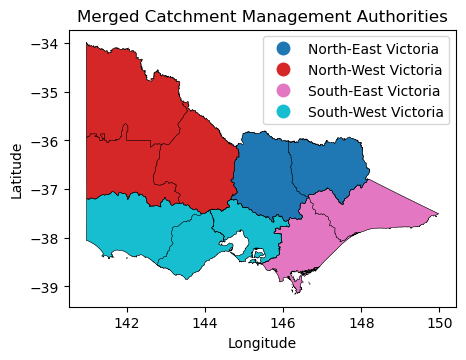

In [16]:
ax = merged_catchment_gdf.plot(
    figsize=[5, 5],
    column='REGION_NAME',
    cmap='tab10',
    legend=True,
    linewidth=0.25,
    edgecolor='black',
#    legend_kwds={'loc': 'right', 'bbox_to_anchor': (1.5, 0.5)},
)

catchment_gdf.plot(
    ax=ax,
    figsize=[5, 5],
    column='CMANAME',
    facecolor='none',
    legend=False,
    linewidth=0.25,
    edgecolor='black',
)

plt.title('Merged Catchment Management Authorities')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Alternative method 1: Supplied by VicWACI

In [17]:
vicwaci_file = '/g/data/xv83/dbi599/vicwaci/shapefiles/Vic_regionalisation.shp'
vicwaci_gdf = gp.read_file(vicwaci_file)
vicwaci_gdf

,hydroid,division,rivregname,srcfcname,srcftype,srctype,sourceid,featrel,fsource,attrrel,...,FSource_2,AttrRel_2,AttrSour_1,PlanAcc_2,Symbol_2,TextNote_2,AlbersAr_1,Shape_Leng,Shape_Area,geometry
0,43637142,Murray-Darling Basin,North-West,None,None,0,0,2019-08-21,Bureau of Meteorology,2019-08-21,...,Bureau of Meteorology,2019-08-21,Bureau of Meteorology,15,0,None,1.062118e+12,99.216667,101.234169,"MULTIPOLYGON (((140.9643 -35.61236, 140.9643 -..."
1,21551945,South East Coast (Victoria),South-East,None,None,0,0,2019-08-21,Bureau of Meteorology,2019-08-21,...,Bureau of Meteorology,2019-08-21,Bureau of Meteorology,15,0,None,1.293330e+11,69.365001,12.381214,"MULTIPOLYGON (((149.9762 -37.50515, 149.97612 ..."
2,21551945,South East Coast (Victoria),North-East,None,None,0,0,2019-08-21,Bureau of Meteorology,2019-08-21,...,Bureau of Meteorology,2019-08-21,Bureau of Meteorology,15,0,None,1.062118e+12,99.216667,101.234169,"MULTIPOLYGON (((144.98264 -37.36986, 144.98264..."
3,21551953,South East Coast (Victoria),South-West,None,None,0,0,2019-08-21,Bureau of Meteorology,2019-08-21,...,Bureau of Meteorology,2019-08-21,Bureau of Meteorology,15,0,None,1.350363e+11,67.081112,13.750868,"MULTIPOLYGON (((144.1257 -38.18818, 144.1257 -..."


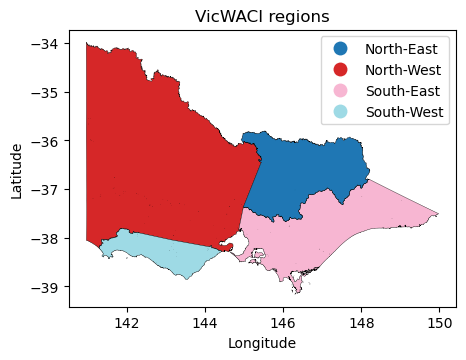

In [18]:
vicwaci_gdf.plot(
    figsize=[5, 5],
    column='rivregname',
    cmap='tab20',
    legend=True,
    linewidth=0.25,
    edgecolor='black',
)
plt.title('VicWACI regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [19]:
#north_east = vicwaci_gdf[vicwaci_gdf['rivregname'] == 'North-East']
#north_east.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/north_east.shp')

In [20]:
#north_west = vicwaci_gdf[vicwaci_gdf['rivregname'] == 'North-West']
#north_west.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/north_west.shp')

In [21]:
#south_east = vicwaci_gdf[vicwaci_gdf['rivregname'] == 'South-East']
#south_east.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/south_east.shp')

In [22]:
#south_west = vicwaci_gdf[vicwaci_gdf['rivregname'] == 'South-West']
#south_west.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/south_west.shp')

# Alterative method 2: Create from NRM regions

### Victoria shapefile

In [23]:
states_file = '/g/data/jt48/aus-ref-clim-data-nci/shapefiles/data/aus_states_territories/aus_states_territories.shp'
states = gp.read_file(states_file)
states

,STE_NAME21,ABBREV,AREASQKM21,LOCI_URI21,geometry
0,New South Wales,NSW,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ..."
1,Victoria,VIC,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,Queensland,QLD,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ..."
3,South Australia,SA,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,Western Australia,WA,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."
5,Tasmania,TAS,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443..."
6,Northern Territory,NT,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982..."
7,Australian Capital Territory,ACT,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14..."
8,Other Territories,OT,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748..."


In [24]:
victoria = states[states['STE_NAME21'] == 'Victoria']

### NRM regions shapefile

In [25]:
nrm_regions_file = '/g/data/jt48/aus-ref-clim-data-nci/shapefiles/data/nrm_regions/nrm_regions.shp'
nrm_regions = gp.read_file(nrm_regions_file)
nrm_regions

,SubClusNm,SubClusAb,ClusterNm,ClusterAb,SupClusNm,SupClusAb,geometry
0,Wet Tropics,WT,Wet Tropics,WT,Northern Australia,NA,"MULTIPOLYGON (((148.46142 -20.0668, 148.46219 ..."
1,Rangelands (North),RN,Rangelands,R,Rangelands,R,"MULTIPOLYGON (((114.17846 -21.80762, 114.18413..."
2,Monsoonal North (East),MNE,Monsoonal North,MN,Northern Australia,NA,"POLYGON ((146.29458 -18.89926, 146.29742 -18.9..."
3,Monsoonal North (West),MNW,Monsoonal North,MN,Northern Australia,NA,"POLYGON ((137.99467 -16.54112, 137.99491 -16.9..."
4,East Coast (South),ECS,East Coast,EC,Eastern Australia,EA,"POLYGON ((153.53441 -28.17701, 153.53442 -28.1..."
5,Central Slopes,CS,Central Slopes,CS,Eastern Australia,EA,"POLYGON ((147.957 -24.87855, 147.95711 -24.878..."
6,Murray Basin,MB,Murray Basin,MB,Southern Australia,SA,"POLYGON ((145.74765 -32.21733, 145.75054 -32.2..."
7,Southern and South Western Flatlands (West),SSWFW,Southern and South Western Flatlands,SSWF,Southern Australia,SA,"POLYGON ((124.21316 -33.03955, 124.21087 -33.0..."
8,Southern and South Western Flatlands (East),SSWFE,Southern and South Western Flatlands,SSWF,Southern Australia,SA,"POLYGON ((139.35429 -33.09761, 139.35429 -33.0..."
9,Southern Slopes (Vic/NSW East),SSVE,Southern Slopes,SS,Southern Australia,SA,"POLYGON ((150.99392 -34.22148, 150.9943 -34.22..."


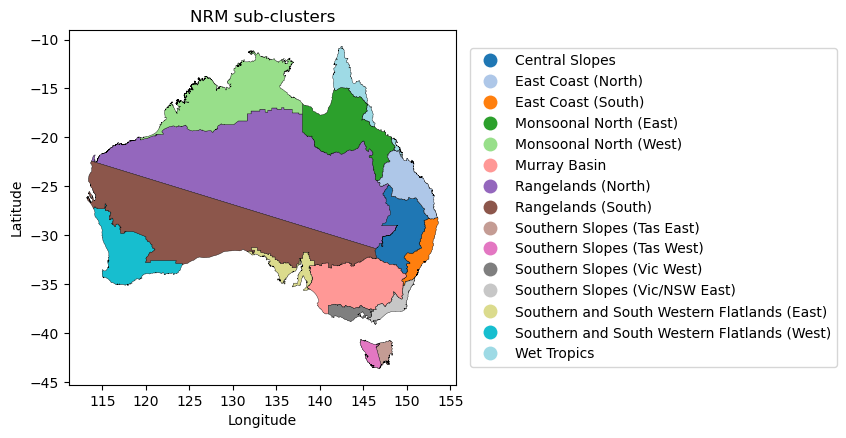

In [26]:
nrm_regions.plot(
    figsize=[5, 5],
    column='SubClusNm',
    cmap='tab20',
    legend=True,
    linewidth=0.25,
    edgecolor='black',
    legend_kwds={'loc': 'right', 'bbox_to_anchor': (2.0, 0.5)},
)
plt.title('NRM sub-clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [27]:
slopes_east = nrm_regions[nrm_regions['SubClusNm'] == 'Southern Slopes (Vic/NSW East)']
slopes_east_vic = slopes_east.overlay(victoria, how='intersection')

In [28]:
slopes_west = nrm_regions[nrm_regions['SubClusNm'] == 'Southern Slopes (Vic West)']
slopes_west_vic = slopes_west.overlay(victoria, how='intersection')

In [29]:
murray_basin = nrm_regions[nrm_regions['SubClusNm'] == 'Murray Basin']
murray_basin_vic = murray_basin.overlay(victoria, how='intersection')

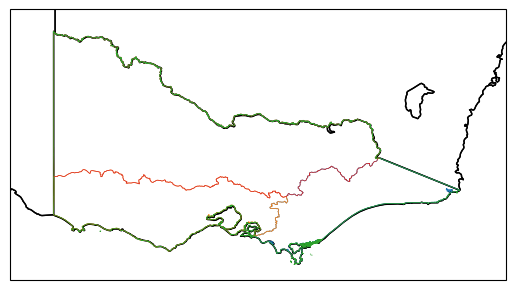

In [30]:
fig = plt.figure()
ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.add_geometries(slopes_east_vic.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5, edgecolor='tab:blue')
ax1.add_geometries(slopes_west_vic.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5,  edgecolor='tab:orange')
ax1.add_geometries(murray_basin_vic.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5,  edgecolor='tab:red')
ax1.add_geometries(victoria.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5,  edgecolor='tab:green')
ax1.set_extent([140, 151, -33.5, -39.5], crs=ccrs.PlateCarree())

plt.show()

In [12]:
slopes_east_vic.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/southern_slopes_east_vic.shp')

In [14]:
slopes_west_vic.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/southern_slopes_west_vic.shp')

In [15]:
murray_basin_vic.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/murray_basin_vic.shp')

In [16]:
victoria.to_file('/g/data/xv83/dbi599/vicwaci/shapefiles/victoria.shp')